# IMDB Sentiment - tokenization et embedding

50 000 critiques de films (positif / negatif). On prepare les donnees pour un LSTM : tokenization (deja faite par keras), padding a 200, et mise en place d'une couche Embedding.

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers
from keras.datasets import imdb
from keras.preprocessing.sequence import pad_sequences
import tensorflow as tf
tf.get_logger().setLevel('ERROR')

VOCAB_SIZE = 10000
MAX_LEN = 200
EMBED_DIM = 128

In [2]:
(X_train_raw, y_train), (X_test_raw, y_test) = imdb.load_data(num_words=VOCAB_SIZE)
print('reviews train:', len(X_train_raw), '| test:', len(X_test_raw))
lengths = [len(x) for x in X_train_raw]
print(f'longueur min/max/moyenne : {min(lengths)} / {max(lengths)} / {np.mean(lengths):.0f}')
print('exemple (review 0, 12 premiers indices):', X_train_raw[0][:12])
print('label review 0:', y_train[0])

reviews train: 25000 | test: 25000
longueur min/max/moyenne : 11 / 2494 / 239
exemple (review 0, 12 premiers indices): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468]
label review 0: 1


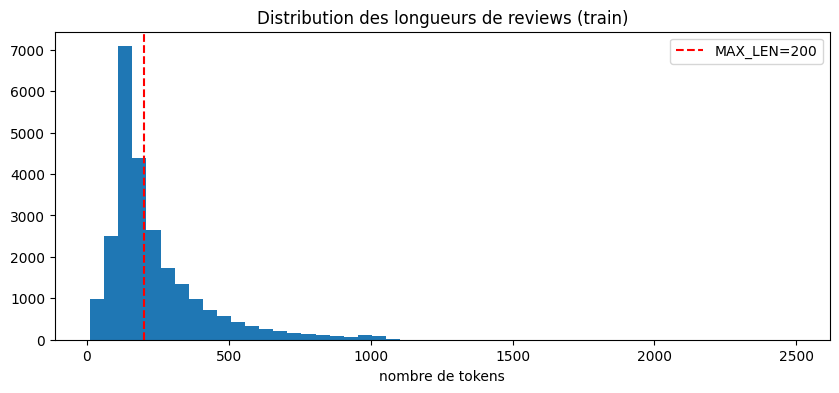

In [3]:
plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=50)
plt.axvline(MAX_LEN, color='r', linestyle='--', label=f'MAX_LEN={MAX_LEN}')
plt.legend()
plt.title('Distribution des longueurs de reviews (train)')
plt.xlabel('nombre de tokens')
plt.show()

In [4]:
# padding='pre' : zeros au debut, vrais tokens pres de la fin (mieux pour le LSTM)
X_train_pad = pad_sequences(X_train_raw, maxlen=MAX_LEN, padding='pre', truncating='pre')
X_test_pad = pad_sequences(X_test_raw, maxlen=MAX_LEN, padding='pre', truncating='pre')
print('X_train_pad:', X_train_pad.shape, '| X_test_pad:', X_test_pad.shape)

X_train_pad: (25000, 200) | X_test_pad: (25000, 200)


In [5]:
# Embedding : chaque indice de mot -> vecteur dense de EMBED_DIM dimensions
demo = keras.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM),
])
demo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,280,000 (4.88 MB)

 Trainable params: 1,280,000 (4.88 MB)

 Non-trainable params: 0 (0.00 B)

# LSTM bidirectionnel - entrainement et evaluation

Embedding -> Bidirectional(LSTM) -> Dropout(0.5) -> Dense(1, sigmoid). Classification binaire (binary_crossentropy), evaluation accuracy + F1.

In [6]:
from sklearn.metrics import f1_score, classification_report
from keras.callbacks import EarlyStopping
keras.utils.set_random_seed(42)

In [7]:
model_imdb = keras.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid'),
])
model_imdb.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_imdb.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,378,945 (5.26 MB)

 Trainable params: 1,378,945 (5.26 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
es = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
history_imdb = model_imdb.fit(
    X_train_pad, y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.1,
    callbacks=[es],
    verbose=2,
)

Epoch 1/3


176/176 - 54s - 307ms/step - accuracy: 0.7796 - loss: 0.4529 - val_accuracy: 0.8692 - val_loss: 0.3157


Epoch 2/3


176/176 - 57s - 327ms/step - accuracy: 0.9021 - loss: 0.2564 - val_accuracy: 0.8728 - val_loss: 0.3243


Epoch 3/3


176/176 - 59s - 335ms/step - accuracy: 0.9180 - loss: 0.2166 - val_accuracy: 0.8576 - val_loss: 0.4771


In [9]:
loss_test, acc_test = model_imdb.evaluate(X_test_pad, y_test, verbose=0)
print(f'Accuracy test : {acc_test:.4f}')

y_pred_proba = model_imdb.predict(X_test_pad, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
f1 = f1_score(y_test, y_pred)
print(f'F1-score test : {f1:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Negatif', 'Positif']))

Accuracy test : 0.8677


F1-score test : 0.8642

              precision    recall  f1-score   support

     Negatif       0.85      0.89      0.87     12500
     Positif       0.89      0.84      0.86     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



In [10]:
model_imdb.save('imdb_sentiment.keras')
print('Modele IMDB sauvegarde : imdb_sentiment.keras')

Modele IMDB sauvegarde : imdb_sentiment.keras


In [11]:
import re
word_index = imdb.get_word_index()
INDEX_FROM = 3

def encode_review(text):
    tokens = [1]
    for w in re.findall(r"[a-z']+", text.lower()):
        idx = word_index.get(w)
        if idx is None or idx + INDEX_FROM >= VOCAB_SIZE:
            tokens.append(2)
        else:
            tokens.append(idx + INDEX_FROM)
    return pad_sequences([tokens], maxlen=MAX_LEN, padding='pre', truncating='pre')

for review in ['Absolutely terrible, boring beyond belief, waste of time',
               'A masterpiece, brilliant and deeply moving, I loved every minute']:
    p = float(model_imdb.predict(encode_review(review), verbose=0)[0, 0])
    label = 'Positif' if p > 0.5 else 'Negatif'
    print(f'{p:.2f} -> {label}  |  {review}')

      0/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

  57344/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step

 188416/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step

 360448/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

 532480/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

...

1449984/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

1548288/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


0.01 -> Negatif  |  Absolutely terrible, boring beyond belief, waste of time

0.98 -> Positif  |  A masterpiece, brilliant and deeply moving, I loved every minute
